<a href="https://colab.research.google.com/github/hussein-fawaz/Energy-Cost-of-Enhancing-Reliability-of-Machine-Learning-Models-for-Edge-IoT-Security/blob/main/Energy_Cost_of_Enhancing_Reliability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import

In [ ]:
# ===============================================================
# 📦 Essential Imports for Energy–Calibration–Reliability Framework
# ===============================================================

import numpy as np
import pandas as pd
import time, os, psutil, threading
import matplotlib.pyplot as plt
from datetime import date
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# ---------------------------------------------------------------
# 🔹 Scikit-learn Core
# ---------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score

# ---------------------------------------------------------------
# 🔹 Energy Monitoring
# ---------------------------------------------------------------
import pyRAPL

# ---------------------------------------------------------------
# 🔹 Imbalance Handling (optional, if using CICIoT or similar)
# ---------------------------------------------------------------
from imblearn.over_sampling import SMOTE

# ---------------------------------------------------------------
# 🔹 Date for experiment tagging
# ---------------------------------------------------------------
today = date.today()


## Dataset Read

In [ ]:
df = pd.read_csv("DATASET_PATH")

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
for col in df.columns:
      if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

protocol_encoder = dict(zip(df['protocol_type'].unique(), range(len(df['protocol_type'].unique()))))
df['protocol_type'] = df['protocol_type'].map(protocol_encoder)
df

In [ ]:
# 1) Build a list of all columns
all_cols = df.columns.tolist()

# 2) Flag duplicates over *all* columns
mask = df.duplicated(subset=all_cols, keep='first')

# 3) Keep only the first occurrence of each fully identical row
df = df[~mask].reset_index(drop=True)


In [ ]:
df['label'].value_counts()

label
DDoS          1640326
DoS            624974
Mirai          209198
Benign         109822
Spoofing        48658
Recon           35441
Web              2487
BruteForce       1303
Name: count, dtype: int64

In [ ]:
X = df.drop('label', axis=1)
y = LabelEncoder().fit_transform(df['label'])
classes = np.unique(y)


## Calibration and Energy Tradeoff  Functions

In [ ]:
# ===============================================================
# Energy Measurement & Calibration Evaluation Framework
# ===============================================================

import numpy as np, time, psutil, os, threading
import pyRAPL
from sklearn.calibration import CalibratedClassifierCV

# ---------------------------------------------------------------
# pyRAPL setup (robust, DRAM fallback)
# ---------------------------------------------------------------
try:
    pyRAPL.setup(devices=[pyRAPL.Device.PKG, pyRAPL.Device.DRAM])
    print("[INFO] pyRAPL initialized with PKG + DRAM")
    PYRAPL_AVAILABLE = True
except pyRAPL.PyRAPLCantRecordEnergyConsumption:
    print("[INFO] DRAM not supported — using PKG only.")
    pyRAPL.setup(devices=[pyRAPL.Device.PKG])
    PYRAPL_AVAILABLE = True
except Exception as e:
    print(f"[WARN] pyRAPL not available ({e}) — using CPU power model.")
    PYRAPL_AVAILABLE = False

class EnergyMonitor:
    """
    Monitors wall time, CPU%, RAM, and energy consumption.
    Uses pyRAPL if available, otherwise estimates from CPU load.
    """
    def __init__(self, cpu_power_watts=4.0, sample_every=0.1, label="task"):
        self.cpu_power_watts = cpu_power_watts
        self.sample_every = sample_every
        self.proc = psutil.Process(os.getpid())
        self.label = label
        self.samples = []
        self._stop = threading.Event()
        self._use_rapl = PYRAPL_AVAILABLE
        if self._use_rapl:
            self._rapl_output = pyRAPL.outputs.DataFrameOutput()
            self._measure = pyRAPL.Measurement(label, output=self._rapl_output)

    def _loop(self):
        self.proc.cpu_percent(None)
        while not self._stop.is_set():
            cpu_p = self.proc.cpu_percent(None)
            rss = self.proc.memory_info().rss
            self.samples.append((time.time(), cpu_p, rss))
            time.sleep(self.sample_every)

    def __enter__(self):
        self.t0 = time.time()
        if self._use_rapl:
            try:
                self._measure.begin()
            except Exception as e:
                print(f"[WARN] pyRAPL measurement failed to start: {e}")
                self._use_rapl = False
        self._thr = threading.Thread(target=self._loop, daemon=True)
        self._thr.start()
        return self

    def __exit__(self, *exc):
        self._stop.set()
        self._thr.join()
        self.wall_time = time.time() - self.t0

        # Always compute CPU and RAM statistics first
        if self.samples:
            _, cpu, rss = zip(*self.samples)
            self.cpu_mean = np.mean(cpu)
            self.rss_peak = max(rss)
        else:
            self.cpu_mean = 0
            self.rss_peak = self.proc.memory_info().rss

        # Compute energy (RAPL or estimated)
        if self._use_rapl:
          try:
              self._measure.end()
              res = self._measure.result
                # optional: debug print
              if hasattr(res, "pkg") and res.pkg is not None:
                  print(res)
                  self.energy_j = float(sum(res.pkg)) / 1e6  # convert μJ → J
              else:
                  print("[WARN] No PKG energy data — using fallback estimate.")
                  self.energy_j = self.wall_time * self.cpu_power_watts * (self.cpu_mean / 100.0)
          except Exception as e:
              print(f"[WARN] pyRAPL energy read failed ({e}); using CPU estimate.")
              self.energy_j = self.wall_time * self.cpu_power_watts * (self.cpu_mean / 100.0)
        else:
          self.energy_j = self.wall_time * self.cpu_power_watts * (self.cpu_mean / 100.0)


        # Estimate DRAM overhead if not measured
        self.energy_j_total = self.energy_j * (1.15 if not self._use_rapl else 1.0)


# ---------------------------------------------------------------
# Training / evaluation with energy
# ---------------------------------------------------------------

def fit_rf(Xtr, ytr):
    clf = RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2, n_jobs=-1,
        random_state=0, class_weight="balanced_subsample"
    )
    with EnergyMonitor(label="train") as mon:
        clf.fit(Xtr, ytr)
    return clf, mon

def eval_model(clf, Xte, yte):
    with EnergyMonitor(label="infer") as mon:
        proba = clf.predict_proba(Xte)
    acc = accuracy_score(yte, np.argmax(proba, axis=1))
    f1m = f1_score(yte, np.argmax(proba, axis=1), average="macro")
    ece = compute_ece(yte, proba)
    brier = multi_brier_score(yte, proba, classes=classes)
    return proba, acc, f1m, ece, brier, mon

[INFO] DRAM not supported — using PKG only.


In [ ]:
# ---------------------------------------------------------------
# Reliability metrics
# ---------------------------------------------------------------
def compute_ece(y_true, proba, n_bins: int = 15):
    y_true = np.asarray(y_true)
    conf = proba.max(axis=1)
    pred = proba.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        m = (conf >= bins[i]) & (conf < bins[i + 1])
        if np.any(m):
            acc_bin = correct[m].mean()
            conf_bin = conf[m].mean()
            ece += (m.mean()) * abs(acc_bin - conf_bin)
    return float(ece)

def multi_brier_score(y_true, proba, classes):
    Y = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((Y - proba) ** 2, axis=1))) or 0


def reliability_diagram(y_true, proba, n_bins=15, title="Reliability Diagram", save_path=None):
    conf = proba.max(axis=1)
    pred = proba.argmax(axis=1)
    correct = (pred == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_acc = []
    bin_conf = []
    for i in range(n_bins):
        m = (conf >= bins[i]) & (conf < bins[i+1])
        if np.any(m):
            bin_acc.append(correct[m].mean())
            bin_conf.append(conf[m].mean())

    plt.figure(figsize=(6,6))
    plt.plot([0,1],[0,1], linestyle='--')
    if len(bin_conf) > 0:
        plt.plot(bin_conf, bin_acc, marker='o')
    plt.xlabel("Confidence")
    plt.ylabel("Empirical accuracy")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


In [ ]:
# ===============================================================
# ⚙️ Calibration & Energy Evaluation with Repeated Fraction Sampling
# ===============================================================

def run_calibration_energy_evaluation(
    X_train_full, y_train_full,
    X_calib_full, y_calib_full,
    X_test, y_test,
    fit_rf_func, eval_model_func,
    fractions=np.linspace(0.1, 1.0, 10),
    repeats=5,
    rng_seed=42
):
    """
    Runs calibration and energy evaluation for multiple training fractions,
    repeating each fraction multiple times for statistical stability.

    Parameters
    ----------
    X_train_full, y_train_full : training data
    X_calib_full, y_calib_full : calibration data
    X_test, y_test : test data
    fit_rf_func : callable
        Function to fit the base model, must return (model, EnergyMonitor)
    eval_model_func : callable
        Function to evaluate a model, must return (proba, acc, f1, ece, brier, EnergyMonitor)
    fractions : list or np.ndarray
        Fractions of the training data to use (e.g., [0.1, 0.2, ..., 1.0])
    repeats : int
        Number of times to repeat random sampling for each fraction (except 1.0)
    rng_seed : int
        Random seed for reproducibility

    Returns
    -------
    df_results : pd.DataFrame
        Averaged metrics across repeats for each training fraction
    """

    rng = np.random.RandomState(rng_seed)
    results_all = []

    def safe_index(X, idx):
        return X.iloc[idx] if hasattr(X, "iloc") else X[idx]

    for frac in fractions:
        print(f"\n[INFO] Processing fraction = {frac:.1f}")

        # Skip repetitions for full training set
        reps = 1 if frac > 0.7 else repeats
        rep_results = []

        for rep in range(reps):
            print(f"  └── Repetition {rep + 1}/{reps}")
            n_train = int(len(X_train_full) * frac)
            idx = rng.choice(len(X_train_full), size=n_train, replace=False)
            Xtr, ytr = safe_index(X_train_full, idx), safe_index(y_train_full, idx)

            # ---- Train base RF ----
            rf, mon_train = fit_rf_func(Xtr, ytr)

            # ---- Uncalibrated ----
            proba_unc, acc_unc, f1_unc, ece_unc, brier_unc, mon_unc = eval_model_func(rf, X_test, y_test)

            # ---- Platt (Sigmoid) ----
            platt = CalibratedClassifierCV(rf, cv="prefit", method="sigmoid")
            # platt.fit(X_calib_full, y_calib_full)
            with EnergyMonitor(label="calib_platt") as mon_cal_platt:
              platt.fit(X_calib_full, y_calib_full)
            proba_pl, acc_pl, f1_pl, ece_pl, brier_pl, mon_pl = eval_model_func(platt, X_test, y_test)

            # ---- Isotonic ----
            iso = CalibratedClassifierCV(rf, cv="prefit", method="isotonic")
            # iso.fit(X_calib_full, y_calib_full)
            with EnergyMonitor(label="calib_iso") as mon_cal_iso:
                iso.fit(X_calib_full, y_calib_full)

            proba_iso, acc_iso, f1_iso, ece_iso, brier_iso, mon_iso = eval_model_func(iso, X_test, y_test)

            # ---- Store results per repetition ----
            rep_results.append({
                "fraction": frac,
                "train_time_s": mon_train.wall_time,
                "train_cpu_mean_%": mon_train.cpu_mean,
                "train_ram_peak_MB": mon_train.rss_peak / (1024 ** 2),
                "train_energy_J": mon_train.energy_j_total,

                "acc_uncal": acc_unc, "f1_uncal": f1_unc, "ece_uncal": ece_unc, "brier_uncal": brier_unc,
                "acc_platt": acc_pl, "f1_platt": f1_pl, "ece_platt": ece_pl, "brier_platt": brier_pl,
                "acc_iso": acc_iso, "f1_iso": f1_iso, "ece_iso": ece_iso, "brier_iso": brier_iso,

                "infer_time_unc_s": mon_unc.wall_time, "infer_energy_unc_J": mon_unc.energy_j_total, "infer_ram_unc_MB": mon_unc.rss_peak / (1024 ** 2),
                "infer_time_platt_s": mon_pl.wall_time, "infer_energy_platt_J": mon_pl.energy_j_total, "infer_ram_platt_MB": mon_pl.rss_peak / (1024 ** 2),
                "infer_time_iso_s": mon_iso.wall_time, "infer_energy_iso_J": mon_iso.energy_j_total, "infer_ram_iso_MB": mon_iso.rss_peak / (1024 ** 2),

                "calib_energy_platt_J": mon_cal_platt.energy_j_total,
                "calib_time_platt_s": mon_cal_platt.wall_time,
                "calib_energy_iso_J": mon_cal_iso.energy_j_total,
                "calib_time_iso_s": mon_cal_iso.wall_time,
                })

        # ---- Average results across repetitions ----
        df_rep = pd.DataFrame(rep_results)
        df_mean = df_rep.mean(numeric_only=True)
        df_std = df_rep.std(numeric_only=True)

        df_mean["fraction"] = frac
        df_mean["repeat_std_acc_uncal"] = df_std["acc_uncal"]
        df_mean["repeat_std_energy_unc"] = df_std["infer_energy_unc_J"]

        results_all.append(df_mean)

    df_results = pd.DataFrame(results_all)
    print("\n✅ Evaluation completed successfully with averaged repetitions.")
    return df_results


In [ ]:
# ===============================================================
# ⚙️ Calibration & Energy Evaluation with Nested Averaging
# ===============================================================

def run_calibration_energy_cv(
    X, y,
    fit_rf_func, eval_model_func,
    outer_splits=10,
    inner_repeats=5,
    fractions=np.linspace(0.1, 1.0, 10),
    test_size=0.2,
    calib_size=0.2,
    rng_seed=42
):
    """
    Performs repeated calibration + energy evaluation with:
      - multiple random 80/20 train-test splits (outer loop)
      - repeated random subset sampling per training fraction (inner loop)
    and averages results across both.

    Returns
    -------
    df_mean : pd.DataFrame
        Mean metrics per fraction (aggregated over all outer and inner loops)
    df_all : pd.DataFrame
        Raw results of all runs (outer × inner × fraction)
    """

    rng_master = np.random.RandomState(rng_seed)
    all_outer_results = []

    for outer_i in range(outer_splits):
        print(f"\n==============================")
        print(f"[INFO] Outer Split {outer_i + 1}/{outer_splits}")
        print(f"==============================")

         # --- Stratified outer split (Train/Test) ---
        X_trainval, X_test, y_trainval, y_test = train_test_split(
            X, y,
            test_size=test_size,
            stratify=y,
            random_state=rng_master.randint(1e6)
        )

        # --- Stratified inner split (Train/Calibration) ---
        X_train_full, X_calib_full, y_train_full, y_calib_full = train_test_split(
            X_trainval, y_trainval,
            test_size=calib_size,
            stratify=y_trainval,
            random_state=rng_master.randint(1e6)
        )

        # --- Run the fraction-based evaluation for this outer split ---
        df_outer = run_calibration_energy_evaluation(
            X_train_full=X_train_full,
            y_train_full=y_train_full,
            X_calib_full=X_calib_full,
            y_calib_full=y_calib_full,
            X_test=X_test,
            y_test=y_test,
            fit_rf_func=fit_rf_func,
            eval_model_func=eval_model_func,
            fractions=fractions,
            repeats=inner_repeats,
            rng_seed=rng_master.randint(1e6)
        )

        df_outer["outer_split"] = outer_i + 1
        all_outer_results.append(df_outer)

    # --- Combine all runs ---
    df_all = pd.concat(all_outer_results, ignore_index=True)

    # --- Aggregate across outer splits ---
    df_mean = df_all.groupby("fraction").mean(numeric_only=True).reset_index()
    df_std = df_all.groupby("fraction").std(numeric_only=True).reset_index()

    # --- Add confidence intervals (±1 std)
    for col in df_mean.columns:
        if col not in ["fraction"]:
            df_mean[f"{col}_std"] = df_std[col]

    # Save the last outer split data for later visualization
    last_split = {
        "X_train_full": X_train_full,
        "X_calib_full": X_calib_full,
        "y_train_full": y_train_full,
        "y_calib_full": y_calib_full,
        "X_test": X_test,
        "y_test": y_test
    }

    df_mean.to_csv("Downloads/WONS/df_mean.csv", index=False)
    df_all.to_csv("Downloads/WONS/df_all.csv", index=False)
    last_split["X_train_full"].to_csv("Downloads/WONS/X_train_full.csv", index=False)
    last_split["y_train_full"].to_csv("Downloads/WONS/y_train_full.csv", index=False)
    last_split["X_calib_full"].to_csv("Downloads/WONS/X_calib_full.csv", index=False)
    last_split["y_calib_full"].to_csv("Downloads/WONS/y_calib_full.csv", index=False)
    last_split["X_test"].to_csv("Downloads/WONS/X_test.csv", index=False)
    last_split["y_test"].to_csv("Downloads/WONS/y_test.csv", index=False)

    pd.Series(last_split["y_train_full"]).to_csv("Downloads/WONS/y_train_full.csv", index=False, header=["label"])
    pd.Series(last_split["y_calib_full"]).to_csv("Downloads/WONS/y_calib_full.csv", index=False, header=["label"])
    pd.Series(last_split["y_test"]).to_csv("Downloads/WONS/y_test.csv", index=False, header=["label"])


    print("\n✅ Completed all splits with aggregated mean & std results.")
    return df_mean, df_all, last_split


## Visualization Functions

In [1]:
# ===============================================================
# 📊 Energy–Reliability Visualization Framework (Reusable Class)
# ===============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV

class CalibrationEnergyVisualizer:
    def __init__(self, df_res, X_train_full, X_calib_full, y_train_full, y_calib_full, X_test, y_test,
                 fit_rf_func, eval_model_func, reliability_diag_func):
        """
        Parameters
        ----------
        df_res : pd.DataFrame
            Results dataframe with metrics for different calibration methods.
        X_train_full, X_calib_full, y_train_full, y_calib_full, X_test, y_test : arrays/DataFrames
            Datasets used in calibration and evaluation.
        fit_rf_func : callable
            Function to train the Random Forest (fit_rf).
        eval_model_func : callable
            Function to evaluate models and return metrics (eval_model).
        reliability_diag_func : callable
            Function to plot reliability diagrams.
        """
        self.df = df_res.copy()
        self.X_train_full = X_train_full
        self.X_calib_full = X_calib_full
        self.y_train_full = y_train_full
        self.y_calib_full = y_calib_full
        self.X_test = X_test
        self.y_test = y_test
        self.fit_rf = fit_rf_func
        self.eval_model = eval_model_func
        self.reliability_diagram = reliability_diag_func
        self.x = self.df["fraction"].values

    # -----------------------------------------------------------
    # Helper: Line plot
    # -----------------------------------------------------------
    def line_plot(self, ys, xlabel, ylabel, title):
        plt.figure(figsize=(7, 4))
        for label, y in ys.items():
            if label in self.df.columns or isinstance(y, (list, np.ndarray, pd.Series)):
                plt.plot(self.x, y, marker="o", label=label)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------------
    # Helper: Scatter plot
    # -----------------------------------------------------------
    def scatter_plot(self, x_list, y_list, labels, xlabel, ylabel, title):
        plt.figure(figsize=(6, 4))
        colors = ["#0072B2", "#E69F00", "#009E73"]
        for i, lbl in enumerate(labels):
            plt.scatter(x_list[i], y_list[i], label=lbl, s=80, color=colors[i % len(colors)])
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------------
    # 🔹 Core Performance, Timing, Energy, Resource Plots
    # -----------------------------------------------------------
    def plot_all_metrics(self):
        df = self.df

        # --- Performance ---
        self.line_plot(
            {"uncalibrated": df["acc_uncal"], "platt": df["acc_platt"], "isotonic": df["acc_iso"]},
            "Training fraction", "Accuracy", "Accuracy vs. Training Fraction"
        )

        self.line_plot(
            {"uncalibrated": df["f1_uncal"], "platt": df["f1_platt"], "isotonic": df["f1_iso"]},
            "Training fraction", "F1 (macro)", "F1-macro vs. Training Fraction"
        )

        self.line_plot(
            {"uncalibrated": df["ece_uncal"], "platt": df["ece_platt"], "isotonic": df["ece_iso"]},
            "Training fraction", "ECE (lower is better)", "Calibration Error vs. Training Fraction"
        )

        self.line_plot(
            {"uncalibrated": df["brier_uncal"], "platt": df["brier_platt"], "isotonic": df["brier_iso"]},
            "Training fraction", "Brier (lower is better)", "Brier Score vs. Training Fraction"
        )

        # --- Timing ---
        self.line_plot({"Training": df["train_time_s"]},
                       "Training fraction", "Seconds", "Training Time vs. Training Fraction")

        self.line_plot(
            {
                "uncalibrated": df["infer_time_unc_s"],
                "platt": df["infer_time_platt_s"],
                "isotonic": df["infer_time_iso_s"],
            },
            "Training fraction", "Seconds (on test set)", "Inference Time vs. Training Fraction"
        )

        # --- Energy ---
        self.line_plot(
            {
                "Uncalibrated": df["infer_energy_unc_J"],
                "Platt": df["infer_energy_platt_J"],
                "Isotonic": df["infer_energy_iso_J"],
            },
            "Training fraction", "Energy (J)", "Energy Consumption vs. Training Fraction"
        )

        # --- Energy Efficiency ---
        df["energy_per_acc_unc"] = df["infer_energy_unc_J"] / df["acc_uncal"]
        df["energy_per_acc_platt"] = df["infer_energy_platt_J"] / df["acc_platt"]
        df["energy_per_acc_iso"] = df["infer_energy_iso_J"] / df["acc_iso"]

        self.line_plot(
            {
                "Uncalibrated": df["energy_per_acc_unc"],
                "Platt": df["energy_per_acc_platt"],
                "Isotonic": df["energy_per_acc_iso"],
            },
            "Training fraction", "Energy per Accuracy (J)", "Energy Efficiency vs. Training Fraction"
        )

        # --- CPU vs Energy ---
        if "train_cpu_mean_%" in df.columns:
            self.line_plot(
                {"CPU Utilization (%)": df["train_cpu_mean_%"],
                 "Training Energy (J)": df["train_energy_J"]},
                "Training fraction", "Value", "CPU Utilization & Training Energy"
            )

        # --- RAM vs Energy ---
        self.line_plot(
            {"Train RAM (MB)": df["train_ram_peak_MB"], "Train Energy (J)": df["train_energy_J"]},
            "Training fraction", "Value", "RAM vs Energy Consumption (Training)"
        )

        # --- Memory ---
        self.line_plot(
            {
                "Training": df["train_ram_peak_MB"],
                "Uncalibrated": df["infer_ram_unc_MB"],
                "Platt": df["infer_ram_platt_MB"],
                "Isotonic": df["infer_ram_iso_MB"],
            },
            "Training fraction", "Peak RAM (MB)", "RAM Usage vs. Training Fraction"
        )

        # --- CPU Utilization ---
        if "train_cpu_mean_%" in df.columns:
            self.line_plot(
                {"Mean CPU Usage (%)": df["train_cpu_mean_%"]},
                "Training fraction", "CPU Utilization (%)", "CPU Utilization vs. Training Fraction"
            )



    # -----------------------------------------------------------
    # ⚖️ Energy–Reliability Trade-offs
    # -----------------------------------------------------------
    def plot_tradeoffs(self):
        df = self.df

        # --- Reliability Index ---
        df["reliability_index_unc"] = 0.5 * (df["ece_uncal"] + df["brier_uncal"])
        df["reliability_index_platt"] = 0.5 * (df["ece_platt"] + df["brier_platt"])
        df["reliability_index_iso"] = 0.5 * (df["ece_iso"] + df["brier_iso"])

        self.scatter_plot(
            [df["infer_energy_unc_J"], df["infer_energy_platt_J"], df["infer_energy_iso_J"]],
            [df["ece_uncal"], df["ece_platt"], df["ece_iso"]],
            ["Uncalibrated", "Platt", "Isotonic"],
            "Inference Energy (J)", "ECE (↓ better)", "Reliability vs Energy (ECE)"
        )

        self.scatter_plot(
            [df["infer_energy_unc_J"], df["infer_energy_platt_J"], df["infer_energy_iso_J"]],
            [df["brier_uncal"], df["brier_platt"], df["brier_iso"]],
            ["Uncalibrated", "Platt", "Isotonic"],
            "Inference Energy (J)", "Brier Score (↓ better)", "Brier vs Energy"
        )

        self.scatter_plot(
            [df["infer_energy_unc_J"], df["infer_energy_platt_J"], df["infer_energy_iso_J"]],
            [df["reliability_index_unc"], df["reliability_index_platt"], df["reliability_index_iso"]],
            ["Uncalibrated", "Platt", "Isotonic"],
            "Inference Energy (J)", "Combined Reliability Index (↓ better)", "Reliability–Energy Trade-off"
        )

        self.scatter_plot(
            [df["infer_energy_unc_J"], df["infer_energy_platt_J"], df["infer_energy_iso_J"]],
            [df["acc_uncal"], df["acc_platt"], df["acc_iso"]],
            ["Uncalibrated", "Platt", "Isotonic"],
            "Inference Energy (J)", "Accuracy", "Accuracy vs Energy"
        )

        self.scatter_plot(
            [df["infer_energy_unc_J"], df["infer_energy_platt_J"], df["infer_energy_iso_J"]],
            [df["f1_uncal"], df["f1_platt"], df["f1_iso"]],
            ["Uncalibrated", "Platt", "Isotonic"],
            "Inference Energy (J)", "F1 (macro)", "F1 Score vs Energy"
        )

        # --- RAM & CPU vs Energy ---
        if "train_cpu_mean_%" in df.columns:
            self.scatter_plot(
                [df["infer_energy_unc_J"], df["infer_energy_platt_J"], df["infer_energy_iso_J"]],
                [df["train_cpu_mean_%"]]*3,
                ["Uncalibrated", "Platt", "Isotonic"],
                "Inference Energy (J)", "CPU Utilization (%)", "CPU Utilization vs Energy"
            )

        self.scatter_plot(
            [df["infer_energy_unc_J"], df["infer_energy_platt_J"], df["infer_energy_iso_J"]],
            [df["infer_ram_unc_MB"], df["infer_ram_platt_MB"], df["infer_ram_iso_MB"]],
            ["Uncalibrated", "Platt", "Isotonic"],
            "Inference Energy (J)", "Peak RAM (MB)", "RAM Usage vs Energy"
        )

        # --- Energy × Reliability Efficiency ---
        df["energy_per_reliability_unc"] = df["infer_energy_unc_J"] * df["reliability_index_unc"]
        df["energy_per_reliability_platt"] = df["infer_energy_platt_J"] * df["reliability_index_platt"]
        df["energy_per_reliability_iso"] = df["infer_energy_iso_J"] * df["reliability_index_iso"]

        self.scatter_plot(
            [df["energy_per_reliability_unc"], df["energy_per_reliability_platt"], df["energy_per_reliability_iso"]],
            [df["reliability_index_unc"], df["reliability_index_platt"], df["reliability_index_iso"]],
            ["Uncalibrated", "Platt", "Isotonic"],
            "Energy × Reliability (↓ = efficient)", "Combined Reliability (↓ better)", "Energy–Reliability Efficiency Frontier"
        )

    # -----------------------------------------------------------
    # Reliability Diagrams for full training fraction
    # -----------------------------------------------------------
    def plot_reliability_diagrams(self):
        rf_full, _ = self.fit_rf(self.X_train_full, self.y_train_full)
        proba_unc_full, _, _, _, _, _ = self.eval_model(rf_full, self.X_test, self.y_test)

        platt_full = CalibratedClassifierCV(rf_full, cv="prefit", method="sigmoid")
        platt_full.fit(self.X_calib_full, self.y_calib_full)
        proba_pl_full, _, _, _, _, _ = self.eval_model(platt_full, self.X_test, self.y_test)

        iso_full = CalibratedClassifierCV(rf_full, cv="prefit", method="isotonic")
        iso_full.fit(self.X_calib_full, self.y_calib_full)
        proba_iso_full, _, _, _, _, _ = self.eval_model(iso_full, self.X_test, self.y_test)

        self.reliability_diagram(self.y_test, proba_unc_full, title="Reliability: Uncalibrated RF (Full Data)")
        self.reliability_diagram(self.y_test, proba_pl_full, title="Reliability: Platt-Calibrated RF (Full Data)")
        self.reliability_diagram(self.y_test, proba_iso_full, title="Reliability: Isotonic-Calibrated RF (Full Data)")


In [2]:
# ===============================================================
# 📊 Confidence–Performance Frontier (Uncalibrated, Platt, Isotonic)
# ===============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_confidence_performance_frontier_all(df_all, metric="f1", conf_metric="ece"):
    """
    Plots model performance (F1, Accuracy, etc.) vs model confidence (1 - ECE)
    for Uncalibrated, Platt, and Isotonic models, across multiple CV iterations.

    Parameters
    ----------
    df_all : pd.DataFrame
        Combined results across outer × inner loops (output from run_calibration_energy_cv)
    metric : str
        Performance metric to use (e.g., 'f1', 'acc')
    conf_metric : str
        Calibration metric used for confidence (e.g., 'ece')
    """

    methods = ["uncal", "platt", "iso"]
    titles = ["Uncalibrated", "Platt Scaling", "Isotonic Calibration"]
    colors = ["#0072B2", "#E69F00", "#009E73"]

    # Compute confidence = 1 - ECE for each method
    for m in methods:
        df_all[f"conf_{m}"] = 1.0 - df_all[f"{conf_metric}_{m}"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, method, title, color in zip(axes, methods, titles, colors):

        # Group by outer_split and compute mean/stdev across fractions
        grouped = df_all.groupby(["outer_split", "fraction"], as_index=False)[
            [f"{metric}_{method}", f"conf_{method}"]
        ].mean()

        # Aggregate across outer splits to get mean curve and CI
        df_mean = grouped.groupby("fraction").mean().reset_index()
        df_std = grouped.groupby("fraction").std().reset_index()

        x = df_mean[f"conf_{method}"]
        y = df_mean[f"{metric}_{method}"]
        y_std = df_std[f"{metric}_{method}"]

        # Plot individual outer split lines (translucent)
        for split_id in grouped["outer_split"].unique():
            df_split = grouped[grouped["outer_split"] == split_id]
            ax.plot(
                df_split[f"conf_{method}"],
                df_split[f"{metric}_{method}"],
                linestyle="-",
                alpha=0.4,
                color=color,
                linewidth=1
            )

        # Mean line + confidence interval
        ax.plot(x, y, color=color, linewidth=2.5, label="Mean")
        ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.2, label="±1 std")

        ax.set_title(title)
        ax.set_xlabel("Model Confidence (1 - ECE)")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(f"{metric.upper()} Score")
    fig.suptitle("Confidence–Performance Frontiers Across Calibrations", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [3]:
# ===============================================================
# ⚡ Confidence–Energy Frontier (Auto-Adaptive Column Detection)
# ===============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_confidence_energy(df_all, energy_stage="infer", conf_metric="ece"):
    """
    Plots model energy consumption vs model confidence (1 - ECE)
    for Uncalibrated, Platt, and Isotonic models, across multiple CV iterations.
    Automatically adapts to either *_unc or *_uncal naming.
    """

    # Detect naming scheme (some users used 'uncal', others 'unc')
    if any("uncal" in c for c in df_all.columns):
        name_map = {"unc": "uncal", "platt": "platt", "iso": "iso"}
    else:
        name_map = {"unc": "unc", "platt": "platt", "iso": "iso"}

    methods = ["unc", "platt", "iso"]
    titles = ["Uncalibrated", "Platt Scaling", "Isotonic Calibration"]
    colors = ["#0072B2", "#E69F00", "#009E73"]

    # Compute confidence = 1 - ECE for each method if not already present
    for m in methods:
        long_m = name_map[m]
        conf_col = f"conf_{long_m}"
        ece_col = f"{conf_metric}_{long_m}"

        if conf_col not in df_all.columns:
            if ece_col in df_all.columns:
                df_all[conf_col] = 1.0 - df_all[ece_col]
            else:
                raise KeyError(f"Missing column '{ece_col}' in df_all")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, method, title, color in zip(axes, methods, titles, colors):
        long_m = name_map[method]

        metric_col = f"{energy_stage}_energy_{long_m}_J"  # e.g. infer_energy_unc_J or infer_energy_uncal_J
        conf_col = f"conf_{long_m}"

        # Try alternative column name if not found
        if metric_col not in df_all.columns:
            alt_col = metric_col.replace("uncal", "unc") if "uncal" in metric_col else metric_col.replace("unc", "uncal")
            if alt_col in df_all.columns:
                metric_col = alt_col
            else:
                raise KeyError(f"Missing energy column for {method} (tried '{metric_col}' and '{alt_col}')")

        # --- Group by outer_split and compute per-fraction averages ---
        grouped = df_all.groupby(["outer_split", "fraction"], as_index=False)[
            [metric_col, conf_col]
        ].mean()

        # --- Mean and std across outer splits ---
        df_mean = grouped.groupby("fraction").mean().reset_index()
        df_std = grouped.groupby("fraction").std().reset_index()

        x = df_mean[conf_col]
        y = df_mean[metric_col]
        y_std = df_std[metric_col]

        # --- Plot per-split trajectories ---
        for split_id in grouped["outer_split"].unique():
            df_split = grouped[grouped["outer_split"] == split_id]
            ax.plot(
                df_split[conf_col],
                df_split[metric_col],
                linestyle="-",
                alpha=0.4,
                color=color,
                linewidth=1
            )

        # --- Mean curve + Confidence band ---
        ax.plot(x, y, color=color, linewidth=2.5, label="Mean")
        ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.2, label="±1 std")

        ax.set_title(title)
        ax.set_xlabel("Model Confidence (1 - ECE)")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Energy Consumption (J)")
    fig.suptitle("Confidence–Energy Frontiers Across Calibrations", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

##CICIOT23 Results

What to look at?



| Research Question                                  | Metric(s) involved                         |
| -------------------------------------------------- | ------------------------------------------ |
| How does calibration affect model trustworthiness? | ECE, Brier, Reliability Index              |
| How much energy does improved calibration cost?    | infer_energy_J, energy_per_acc             |
| Are better-calibrated models more resource-hungry? | train_ram_peak_MB, train_cpu_mean_%        |
| Is there an optimal calibration–energy tradeoff?   | energy_per_reliability                     |
| How feasible is on-device deployment (edge IoT)?   | infer_energy_J, infer_ram_MB, infer_time_s |



| Column                 | Meaning                                | Unit    | Source                     |
| ---------------------- | -------------------------------------- | ------- | -------------------------- |
| `infer_time_unc_s`     | Time for uncalibrated inference        | seconds | `mon_unc.wall_time`        |
| `infer_time_platt_s`   | Time for Platt-calibrated inference    | seconds | `mon_pl.wall_time`         |
| `infer_time_iso_s`     | Time for Isotonic-calibrated inference | seconds | `mon_iso.wall_time`        |
| `infer_energy_unc_J`   | Energy for uncalibrated inference      | J       | `mon_unc.energy_j_total`   |
| `infer_energy_platt_J` | Energy for Platt inference             | J       | `mon_pl.energy_j_total`    |
| `infer_energy_iso_J`   | Energy for Isotonic inference          | J       | `mon_iso.energy_j_total`   |
| `infer_ram_unc_MB`     | RAM used during uncalibrated inference | MB      | `mon_unc.rss_peak / 1024²` |
| `infer_ram_platt_MB`   | RAM used during Platt inference        | MB      | `mon_pl.rss_peak / 1024²`  |
| `infer_ram_iso_MB`     | RAM used during Isotonic inference     | MB      | `mon_iso.rss_peak / 1024²` |


In [ ]:
df_mean, df_all, last_split = run_calibration_energy_cv(
    X=X,
    y=y,
    fit_rf_func=fit_rf,
    eval_model_func=eval_model
)


[INFO] Outer Split 1/10

[INFO] Processing fraction = 0.1
  └── Repetition 1/5
Result(label='train', timestamp=1763401388.901503, duration=9243198.154, pkg=[217075494.0], dram=None)
Result(label='infer', timestamp=1763401398.1456795, duration=2319384.676, pkg=[51785757.0], dram=None)
Result(label='calib_platt', timestamp=1763401400.8219893, duration=3721138.523, pkg=[65704483.0], dram=None)
Result(label='infer', timestamp=1763401404.5439231, duration=2518768.978, pkg=[54294966.0], dram=None)
Result(label='calib_iso', timestamp=1763401407.402656, duration=2315768.385, pkg=[46200077.0], dram=None)
Result(label='infer', timestamp=1763401409.7195613, duration=2621240.108, pkg=[54564069.0], dram=None)
  └── Repetition 2/5
Result(label='train', timestamp=1763401412.7660506, duration=8903300.661, pkg=[206118368.0], dram=None)
Result(label='infer', timestamp=1763401421.6700249, duration=2323057.127, pkg=[51272513.0], dram=None)
Result(label='calib_platt', timestamp=1763401424.3162992, duratio

In [ ]:
df_mean


,fraction,train_time_s,train_cpu_mean_%,train_ram_peak_MB,train_energy_J,acc_uncal,f1_uncal,ece_uncal,brier_uncal,acc_platt,f1_platt,ece_platt,brier_platt,acc_iso,f1_iso,ece_iso,brier_iso,infer_time_unc_s,infer_energy_unc_J,infer_ram_unc_MB,infer_time_platt_s,infer_energy_platt_J,infer_ram_platt_MB,infer_time_iso_s,infer_energy_iso_J,infer_ram_iso_MB,calib_energy_platt_J,calib_time_platt_s,calib_energy_iso_J,calib_time_iso_s,repeat_std_acc_uncal,repeat_std_energy_unc,outer_split,train_time_s_std,train_cpu_mean_%_std,train_ram_peak_MB_std,train_energy_J_std,acc_uncal_std,f1_uncal_std,ece_uncal_std,brier_uncal_std,acc_platt_std,f1_platt_std,ece_platt_std,brier_platt_std,acc_iso_std,f1_iso_std,ece_iso_std,brier_iso_std,infer_time_unc_s_std,infer_energy_unc_J_std,infer_ram_unc_MB_std,infer_time_platt_s_std,infer_energy_platt_J_std,infer_ram_platt_MB_std,infer_time_iso_s_std,infer_energy_iso_J_std,infer_ram_iso_MB_std,calib_energy_platt_J_std,calib_time_platt_s_std,calib_energy_iso_J_std,calib_time_iso_s_std,repeat_std_acc_uncal_std,repeat_std_energy_unc_std,outer_split_std
0,0.1,8.576451,1834.341118,9629.580078,193.333743,0.988942,0.778530,0.024458,0.020345,0.989510,0.823593,0.005443,0.015951,0.989567,0.822432,0.001494,0.015340,2.131609,45.147104,10190.666719,2.309315,47.728656,10277.826875,2.342393,47.864360,10250.379297,53.433945,3.077708,39.789970,2.045927,0.000196,0.857419,5.5,0.137372,24.653675,385.218397,5.826679,0.000132,0.004499,0.000337,0.000195,0.000112,0.003183,0.000189,0.000151,0.000115,0.003681,0.000109,0.000162,0.055409,1.724712,225.788228,0.066381,1.949143,155.452449,0.062162,1.766794,109.845129,2.221347,0.102707,1.444600,0.048634,0.000062,0.461023,3.02765
1,0.2,17.590464,2199.575961,9958.930156,415.617398,0.990400,0.811205,0.021458,0.017935,0.990681,0.839929,0.004827,0.014220,0.990764,0.839839,0.001328,0.013583,2.238899,47.956868,10785.462891,2.415350,50.222419,10834.321719,2.428712,50.130012,10734.703203,55.959641,3.194914,40.910175,2.076388,0.000135,0.538257,5.5,0.168661,24.833122,140.046832,8.378618,0.000118,0.003064,0.000442,0.000142,0.000122,0.003766,0.000113,0.000172,0.000125,0.003955,0.000115,0.000143,0.032083,1.078409,82.208040,0.038307,1.468125,66.837914,0.040569,1.518122,54.220336,3.392360,0.150462,1.384926,0.058464,0.000031,0.243181,3.02765
2,0.3,27.695243,2385.425422,10133.435781,660.476778,0.991078,0.826931,0.019902,0.016713,0.991244,0.847795,0.004526,0.013359,0.991317,0.847937,0.001224,0.012714,2.301318,49.528087,11024.252656,2.449769,51.224982,11061.352891,2.477291,51.585910,10987.415859,56.376870,3.175430,41.886732,2.113620,0.000097,1.066299,5.5,0.196406,21.347062,94.832036,9.230242,0.000089,0.005495,0.000494,0.000101,0.000096,0.003186,0.000147,0.000128,0.000093,0.003780,0.000087,0.000100,0.014543,0.934550,79.353993,0.029452,0.737050,76.167870,0.044664,1.341591,71.876414,2.174303,0.102251,0.590214,0.017797,0.000032,0.920866,3.02765
3,0.4,38.847539,2502.190393,10318.757500,982.265664,0.991497,0.836856,0.018918,0.015903,0.991598,0.852728,0.004375,0.012816,0.991667,0.853336,0.001197,0.012162,2.327868,50.104119,11189.850234,2.480025,51.918256,11226.507266,2.520409,52.429951,11121.722891,56.010097,3.160440,42.473091,2.135420,0.000107,1.158295,5.5,0.180032,17.009028,83.249754,179.926286,0.000072,0.004393,0.000470,0.000124,0.000086,0.003397,0.000132,0.000106,0.000075,0.003042,0.000081,0.000084,0.024116,0.665896,70.579984,0.028815,0.678974,69.835833,0.013743,0.921069,67.964361,0.949683,0.061722,0.699238,0.028674,0.000026,0.850493,3.02765
4,0.5,49.803947,2564.811493,10877.149219,1189.613666,0.991710,0.841563,0.018308,0.015419,0.991795,0.855919,0.004305,0.012531,0.991871,0.855965,0.001137,0.011853,2.338552,50.677519,11522.260000,2.498088,52.480068,11575.465938,2.511803,52.294402,11429.334063,57.769354,3.252211,42.632784,2.138312,0.000080,1.200471,5.5,0.281825,24.456733,90.223461,12.096111,0.000074,0.003205,0.000269,0.000078,0.000081,0.003383,0.000114,0.000102,0.000072,0.003178,0.000076,0.000074,0.021315,1.014

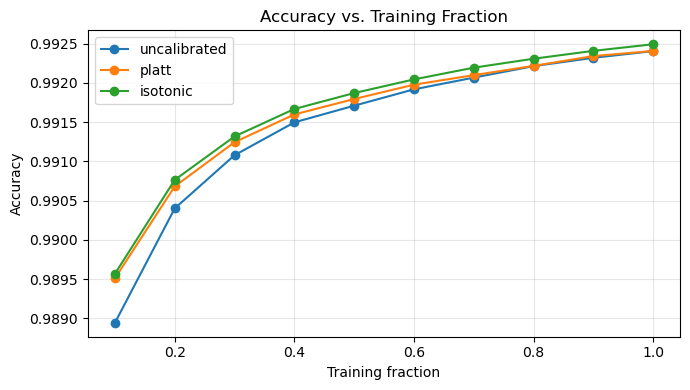

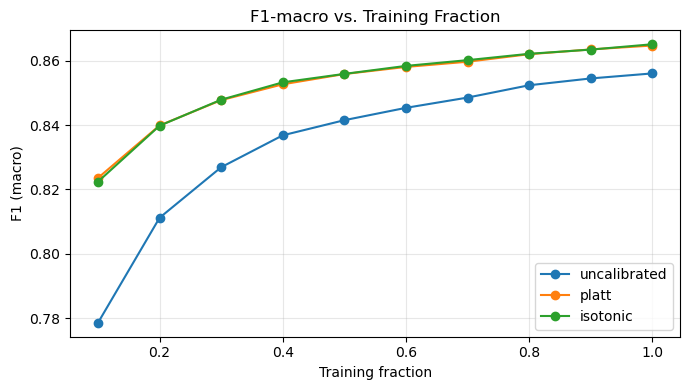

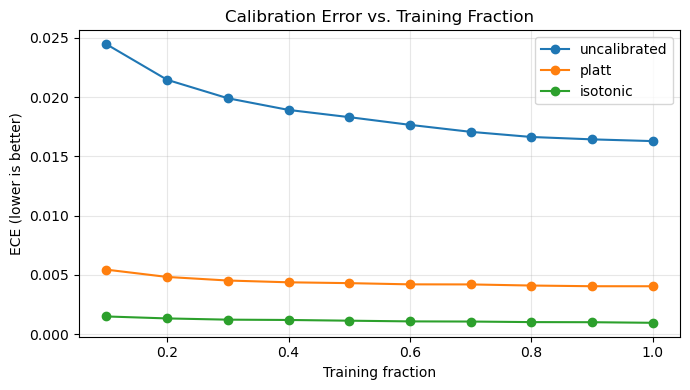

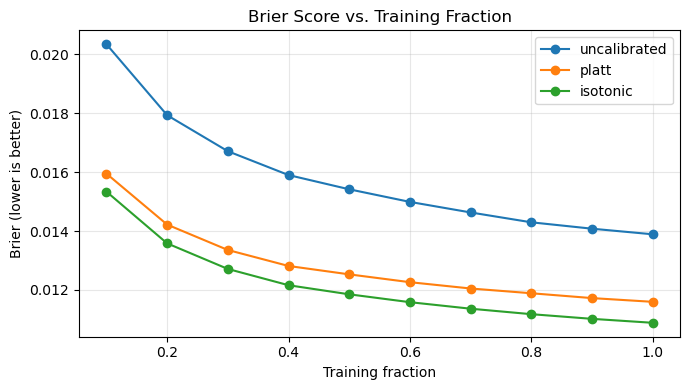

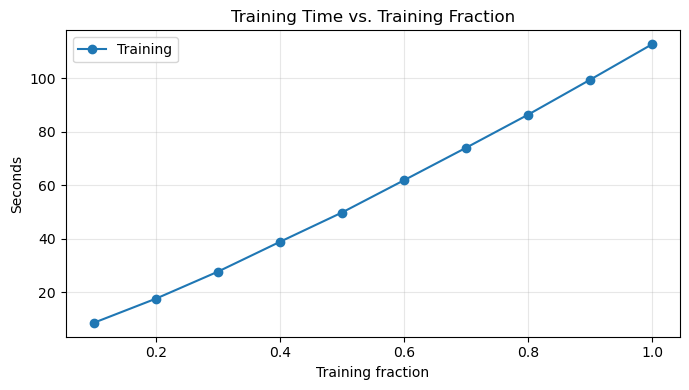

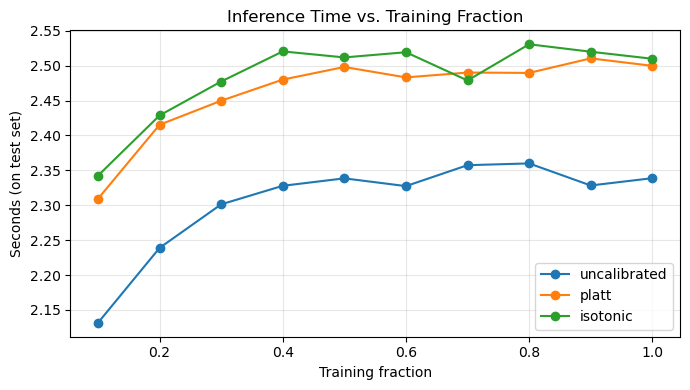

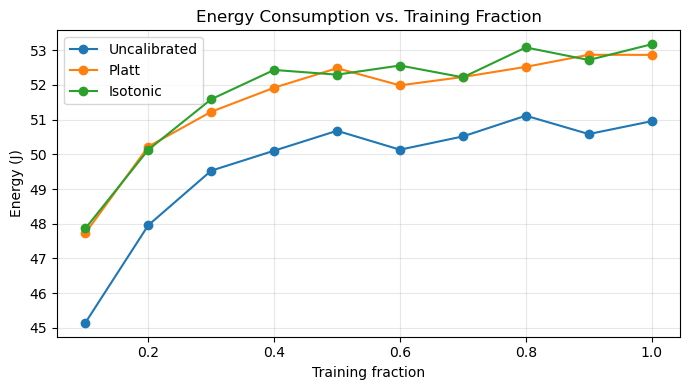

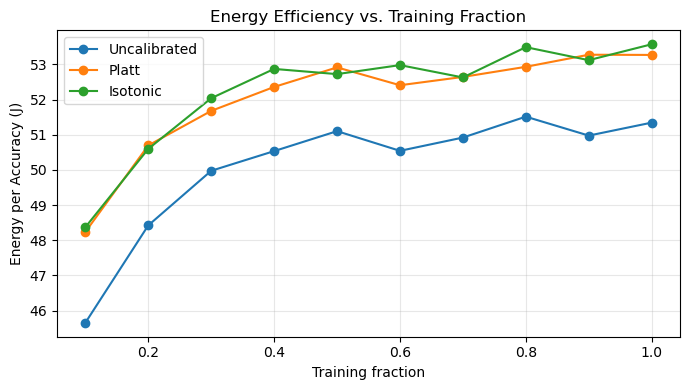

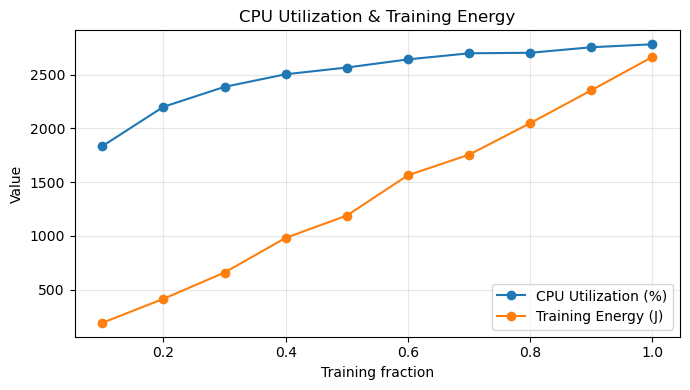

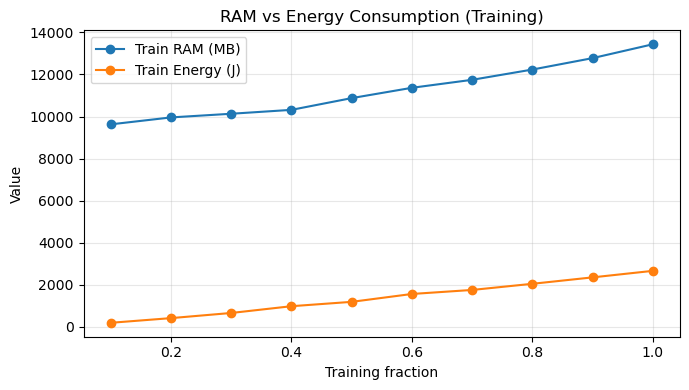

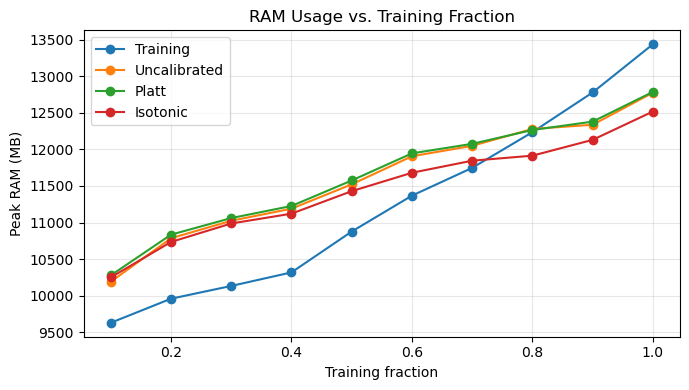

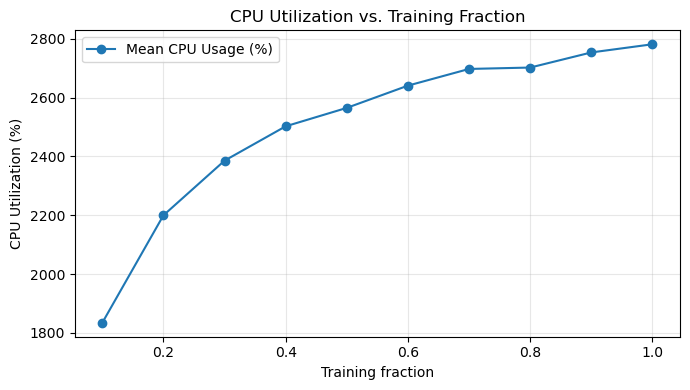

In [ ]:
viz = CalibrationEnergyVisualizer(
    df_res=df_mean,
    X_train_full=last_split["X_train_full"],
    X_calib_full=last_split["X_calib_full"],
    y_train_full=last_split["y_train_full"],
    y_calib_full=last_split["y_calib_full"],
    X_test=last_split["X_test"],
    y_test=last_split["y_test"],
    fit_rf_func=fit_rf,
    eval_model_func=eval_model,
    reliability_diag_func=reliability_diagram
)

viz.plot_all_metrics()

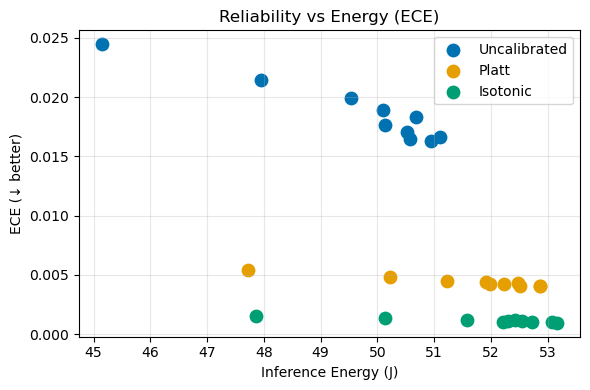

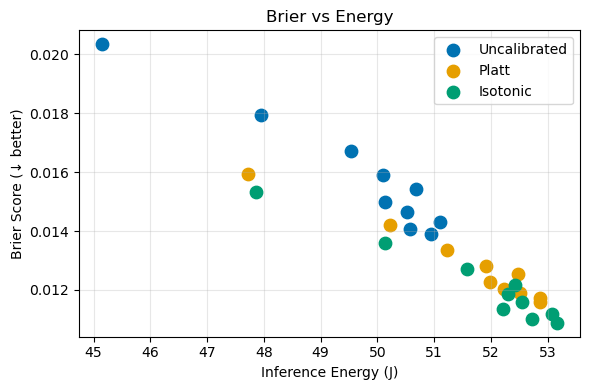

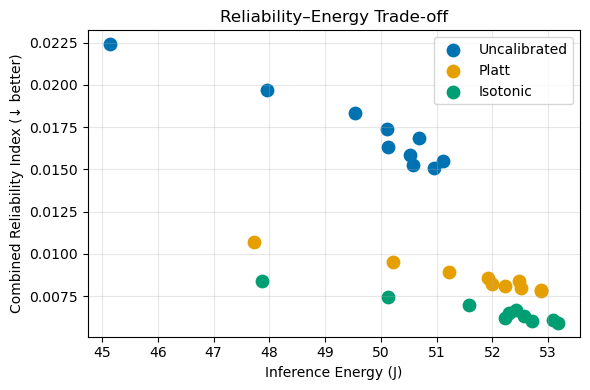

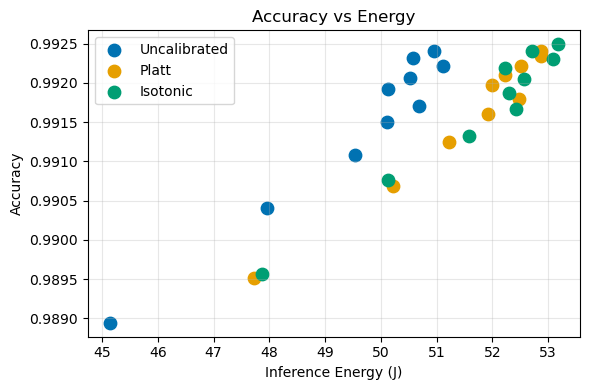

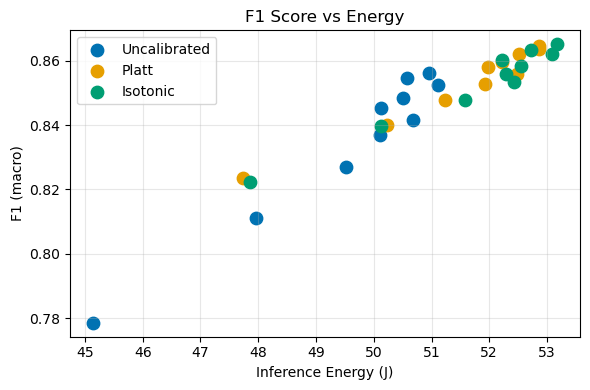

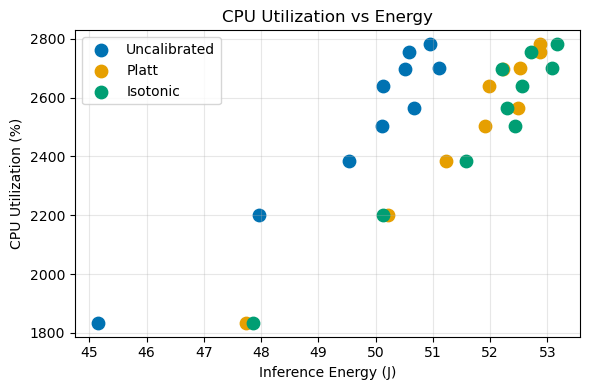

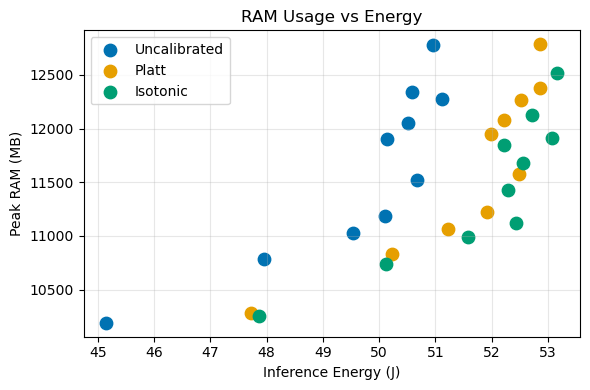

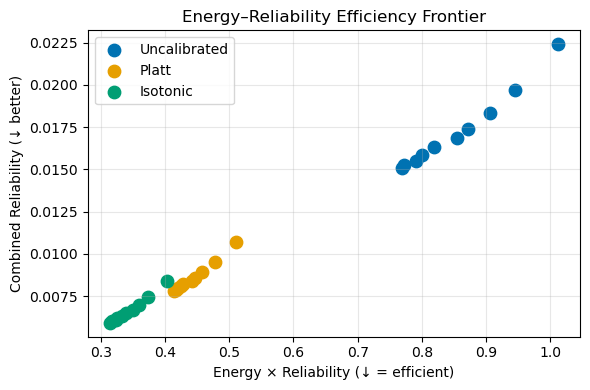

In [ ]:
viz.plot_tradeoffs()


Result(label='train', timestamp=1763420010.6888835, duration=109549186.097, pkg=[2613622825.0], dram=None)
Result(label='infer', timestamp=1763420120.2391725, duration=2518342.214, pkg=[57190528.0], dram=None)
Result(label='infer', timestamp=1763420126.6711802, duration=2418570.385, pkg=[51976795.0], dram=None)
Result(label='infer', timestamp=1763420131.4943147, duration=2518145.85, pkg=[53675827.0], dram=None)


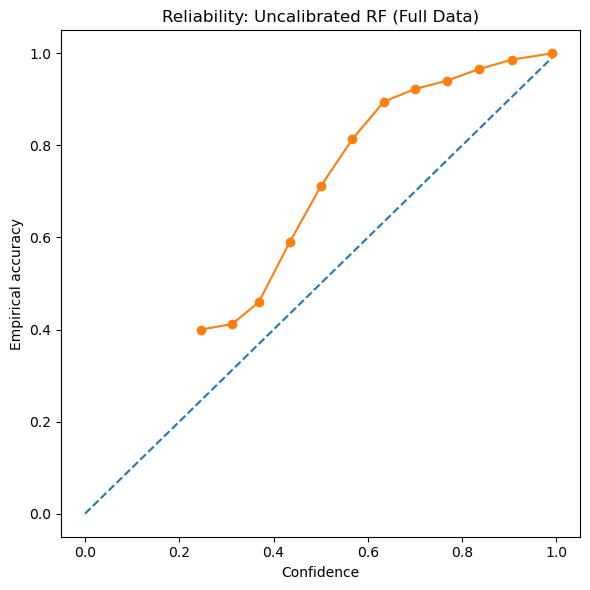

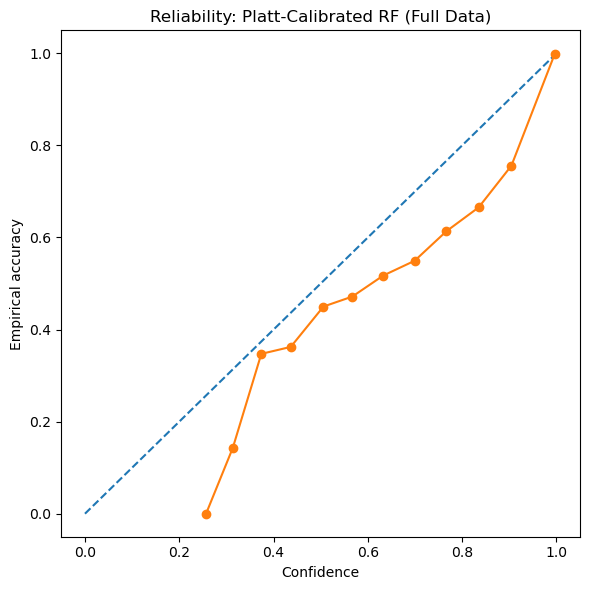

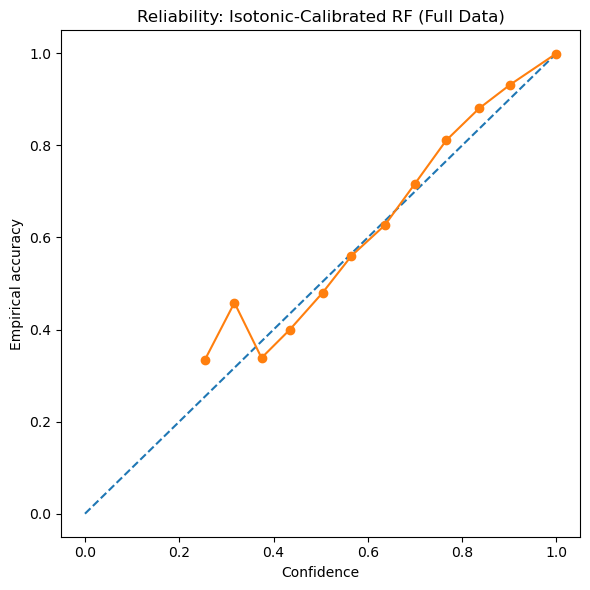

In [ ]:
viz.plot_reliability_diagrams()

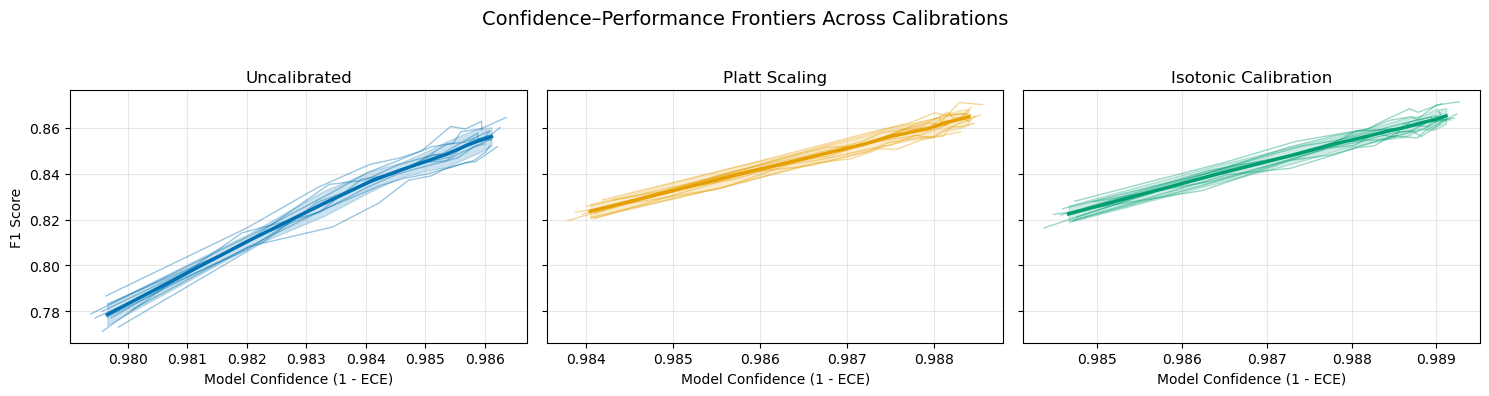

In [ ]:
plot_confidence_performance_frontier_all(df_all, metric="f1", conf_metric="brier")


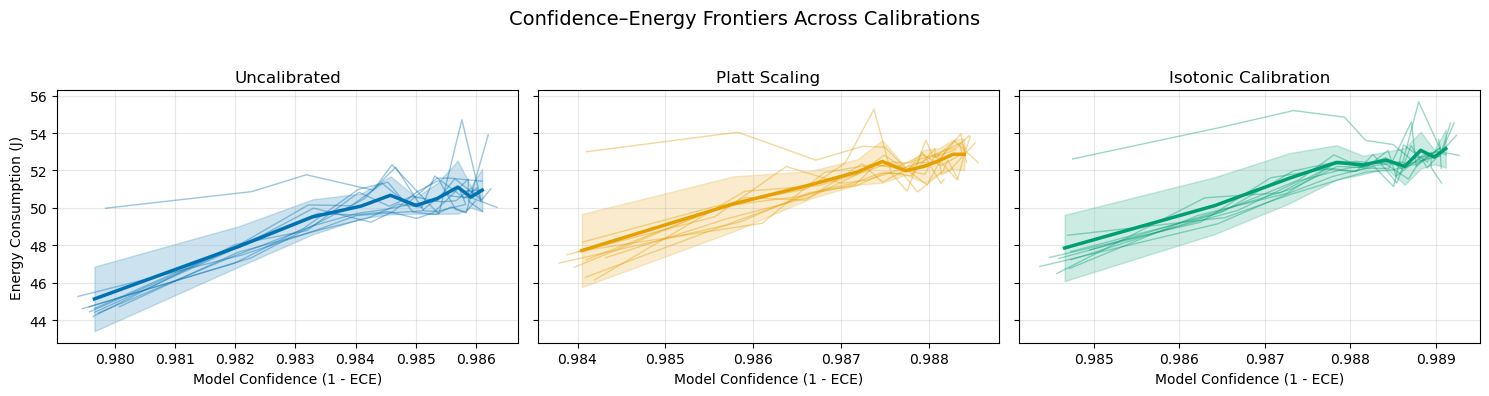

In [ ]:

plot_confidence_energy(df_all, energy_stage="infer")
